# Round 2: Naive Bayes (Multinomial & Complement)


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

sns.set(style='whitegrid')
reports_dir = '/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/reports'
os.makedirs(reports_dir, exist_ok=True)

In [ ]:
train_df = pd.read_excel('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/train.xlsx')
val_df = pd.read_excel('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/val.xlsx')
X_train = train_df['cleaned_poem'].astype(str)
X_val = val_df['cleaned_poem'].astype(str)
y_train_p = train_df['primary_id']
y_val_p = val_df['primary_id']
y_train_s = train_df['secondary_id']
y_val_s = val_df['secondary_id']
with open('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/label_maps.json', 'r') as f:
    maps = json.load(f)
p_map = {v: k for k, v in maps['primary_map'].items()}
s_map = {v: k for k, v in maps['secondary_map'].items()}

In [ ]:
vectorizer = TfidfVectorizer(analyzer='word', stop_words='english', max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

In [ ]:
def train_evaluate_nb(model_cls, y_train, y_val, label_map, prefix):
    print(f"\nTraining {prefix}...")
    model = model_cls()
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_val_vec)
    
    acc = accuracy_score(y_val, y_pred)
    f1_w = f1_score(y_val, y_pred, average='weighted')
    prec_w = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec_w = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted F1: {f1_w:.4f}")
    print(f"Weighted Precision: {prec_w:.4f}")
    print(f"Weighted Recall: {rec_w:.4f}")
    
    metrics = {'accuracy': acc, 'weighted_f1': f1_w, 'weighted_precision': prec_w, 'weighted_recall': rec_w}
    with open(f'{reports_dir}/{prefix}_metrics.json', 'w') as f:
        json.dump(metrics, f, indent=4)
        
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap='Oranges', fmt='d')
    plt.title(f'{prefix} Confusion Matrix')
    plt.savefig(f'{reports_dir}/{prefix}_confusion_matrix.png')
    plt.show()
    
    res = pd.DataFrame({'True': y_val, 'Pred': y_pred})
    res['True_Label'] = res['True'].map(label_map)
    res['Pred_Label'] = res['Pred'].map(label_map)
    res[res['True'] != res['Pred']].to_csv(f'{reports_dir}/{prefix}_errors.csv', index=False)


Training mnb_primary...
Accuracy: 0.3321
Weighted F1: 0.2164
Weighted Precision: 0.1704
Weighted Recall: 0.3321


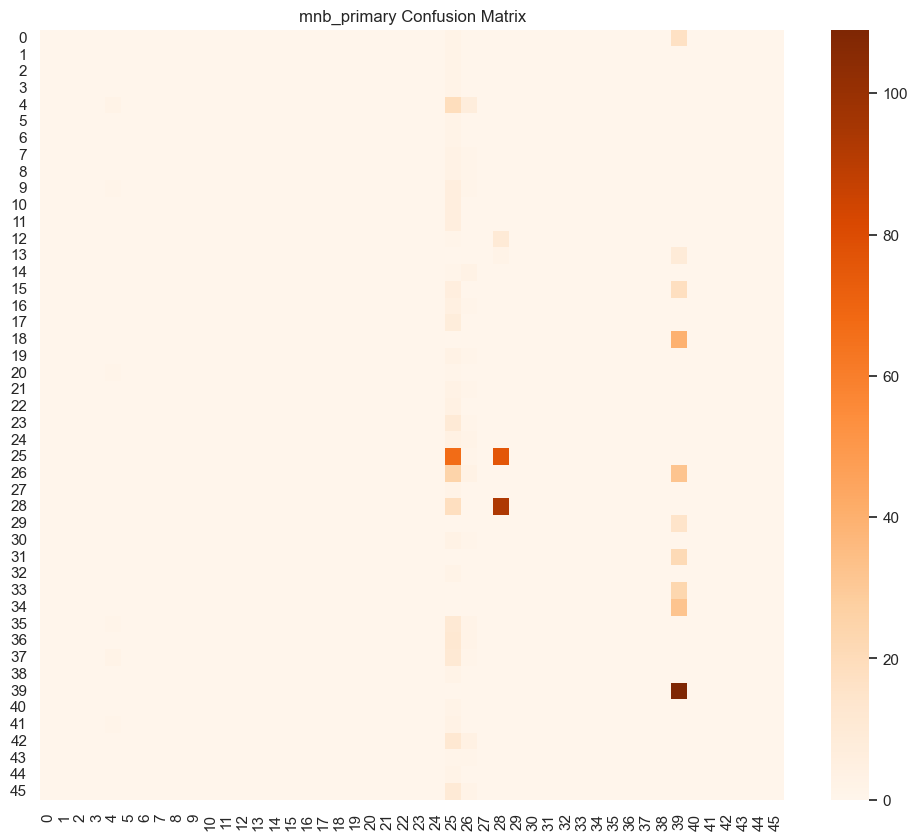


Training mnb_secondary...
Accuracy: 0.2861
Weighted F1: 0.1469
Weighted Precision: 0.1324
Weighted Recall: 0.2861


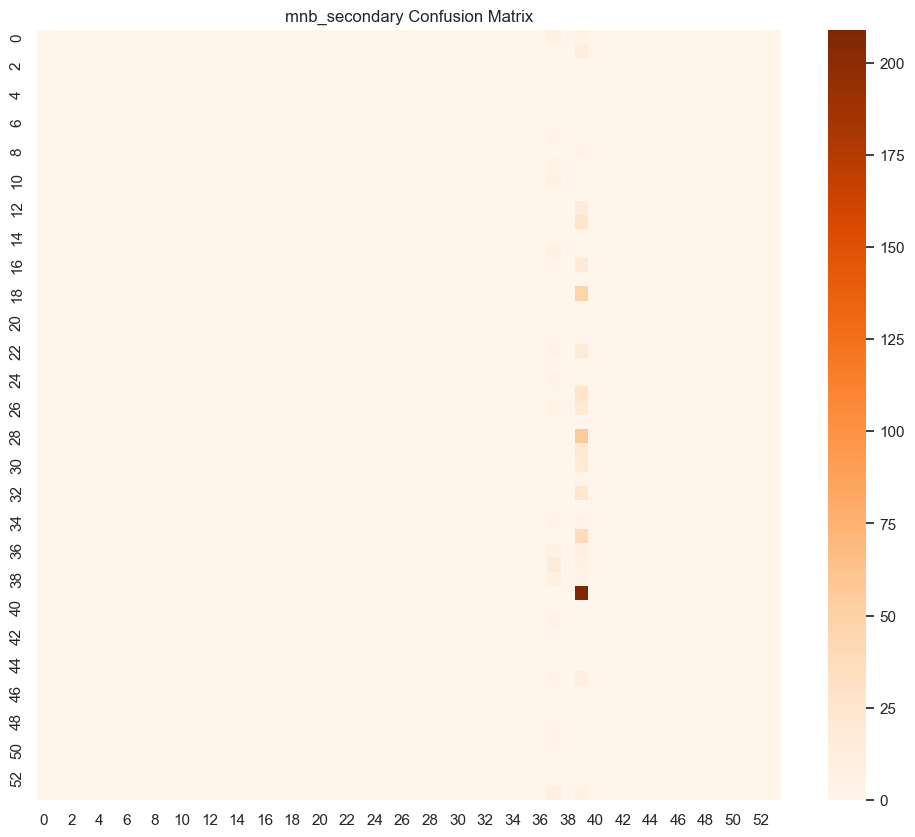


Training cnb_primary...
Accuracy: 0.3552
Weighted F1: 0.2676
Weighted Precision: 0.3231
Weighted Recall: 0.3552


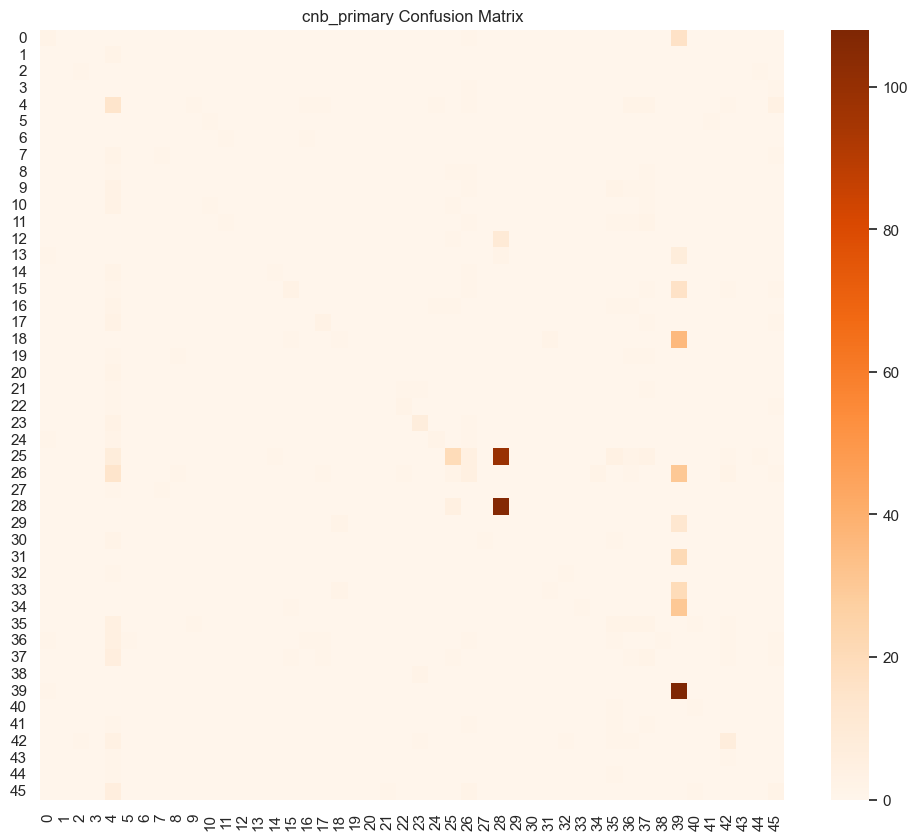


Training cnb_secondary...
Accuracy: 0.2994
Weighted F1: 0.2361
Weighted Precision: 0.2222
Weighted Recall: 0.2994


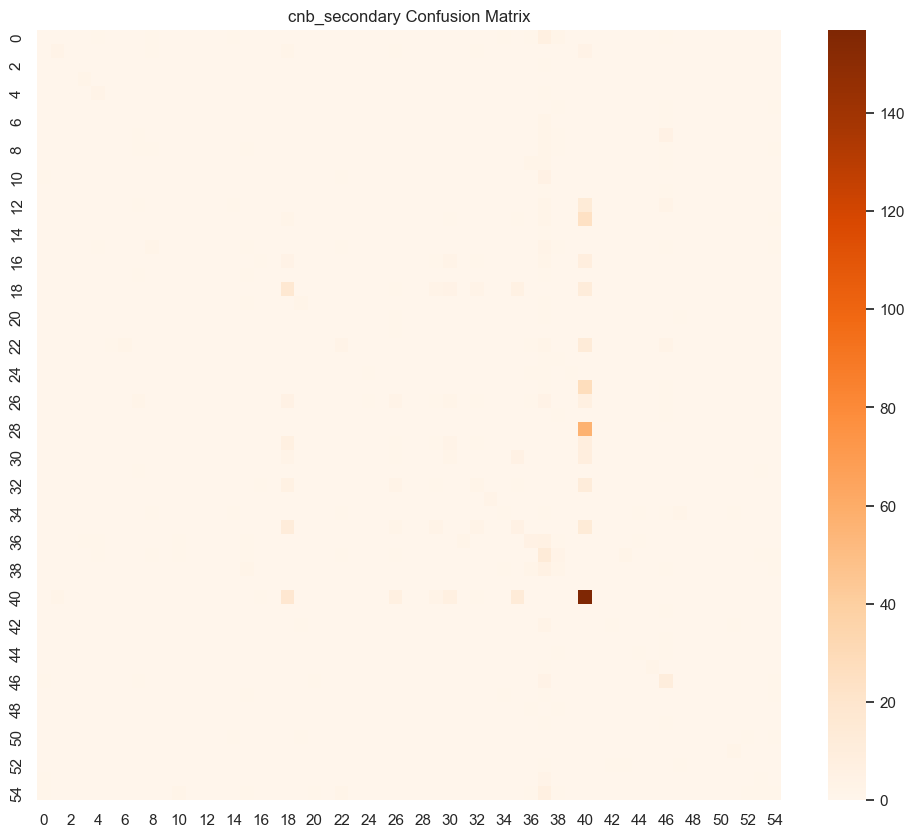

In [ ]:
train_evaluate_nb(MultinomialNB, y_train_p, y_val_p, p_map, 'mnb_primary')
train_evaluate_nb(MultinomialNB, y_train_s, y_val_s, s_map, 'mnb_secondary')
train_evaluate_nb(ComplementNB, y_train_p, y_val_p, p_map, 'cnb_primary')
train_evaluate_nb(ComplementNB, y_train_s, y_val_s, s_map, 'cnb_secondary')